# Baseline Controlled Pendulum


## Goal
Build the simplest closed-loop controlled pendulum using FMU components and compare it against a monolithic Modelica reference simulation.

## Model Map
- `SineAngleSetPoint` → `PIDContinuous` → `DriveDynamic` → `Pendulum`
- Feedback: `theta` from pendulum to PID

![System Graph](figures/graphs/01_baseline_graph.svg)

## Assumptions and Scope
- No sensors/decoders and no contact
- Fixed-step co-simulation; reference uses variable-step DASSL

## Baseline Parameters
These parameters reflect the default values in the Modelica models and serve as the shared baseline for this case study.

In [1]:
import numpy as np

baseline_params = {
    "trajectory": {
        "offset_rad": 0.0,
        "amplitude_rad": np.pi / 9,
        "frequency_hz": 0.25,
        "phase_rad": 0.0,
        "start_time_s": 0.0,
    },
    "pendulum": {
        "m_kg": 10.8429606,
        "L_m": 0.181650853,
        "J_kgm2": 0.442268222,
        "g_m_s2": 9.81,
        "theta_start_rad": 0.0,
        "omega_start_rad_s": 0.0,
    },
    "pid": {
        "kp": 20,
        "ki": 5,
        "kd": 0.01,
        "td": 0.6,
        "nd": 10,
        "u_min": -1,
        "u_max": 1,
    },
    "drive": {
        "V_supply": 16,
        "V_rated": 48,
        "n_0_rpm": 12916,
        "R_arm_Ohm": 0.151,
        "L_arm_H": 121e-6,
        "k_t_Nm_per_A": 0.03,
        "gear_ratio": 60,
        "eta": 0.85,
        "I_max_A": 10,
    },
}

baseline_params


{'trajectory': {'offset_rad': 0.0,
  'amplitude_rad': 0.3490658503988659,
  'frequency_hz': 0.25,
  'phase_rad': 0.0,
  'start_time_s': 0.0},
 'pendulum': {'m_kg': 10.8429606,
  'L_m': 0.181650853,
  'J_kgm2': 0.442268222,
  'g_m_s2': 9.81,
  'theta_start_rad': 0.0,
  'omega_start_rad_s': 0.0},
 'pid': {'kp': 20,
  'ki': 5,
  'kd': 0.01,
  'td': 0.6,
  'nd': 10,
  'u_min': -1,
  'u_max': 1},
 'drive': {'V_supply': 16,
  'V_rated': 48,
  'n_0_rpm': 12916,
  'R_arm_Ohm': 0.151,
  'L_arm_H': 0.000121,
  'k_t_Nm_per_A': 0.03,
  'gear_ratio': 60,
  'eta': 0.85,
  'I_max_A': 10}}

## Prerequisites and Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum import MasterPendulum
import demos.ControlledPendulum.src.master_pendulum.components.fem.pendulum_config as config

from syssimx import FMUComponent, Connection, System, SystemGraphVisualizer

## Discover FMUs

In [3]:
PLATFORM = sys.platform
demo_dir_path = Path().cwd() / "demos" / "ControlledPendulum"
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{PLATFORM}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
        for subsubdir in subdir.iterdir():
            fmu_paths[subdir.name][subsubdir.name] = {}
            if subsubdir.is_dir():
                fmu_paths[subdir.name][subsubdir.name] = {}
                for fmu_file in subsubdir.glob("*.fmu"):
                    fmu_paths[subdir.name][subsubdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

## Modelica Reference Simulation (Monolithic)

```Modelica
within ControlledPendulum.Examples.NoContact;

model Baseline
  // Type definitions
  type RealOutput = Modelica.Blocks.Interfaces.RealOutput;

  // Components
  Trajectories.SineAngleSetPoint set_point;
  Controllers.PIDContinuous      pid;
  Actuators.DriveDynamic         drive;
  Plants.Pendulum                pendulum;

  // FMUCompoent observables
  RealOutput theta_ref(unit="rad") "Reference angle from set point";
  RealOutput theta(unit="rad") "Measured angle from pendulum";
  RealOutput omega(unit="rad/s") "Measured angle from pendulum"; 
  RealOutput alpha(unit="rad/s2") "Measured angle from pendulum";  
  RealOutput u_control(unit="1") "Control input from PID";
  RealOutput tau(unit="N.m") "Torque from drive";

equation
  // Connections
  connect(set_point.theta_ref, pid.theta_ref);
  connect(pendulum.theta, pid.theta_meas);
  connect(pid.u, drive.u_control);
  connect(drive.torque, pendulum.tau);
  connect(drive.omega, pendulum.omega);
  
  pid.resetI = false; // No contact - reset not required
  
  // Observables
  theta_ref = set_point.theta_ref;
  theta = pendulum.theta;
  omega = pendulum.omega;
  alpha = pendulum.alpha;
  u_control = pid.u;
  tau = drive.torque;  
  
  annotation(
    experiment(StartTime = 0, StopTime = 5, Interval = 0.001)
  );

end Baseline;

In [4]:
from OMPython import ModelicaSystem
reference = ModelicaSystem(fileName=str(package_path / "package.mo"),
                           modelName="ControlledPendulum.Examples.NoContact.Baseline")
reference.buildModel()
reference.simulate()
ref_sol_names = ('time', 'theta', 'omega', 'u_control')
ref_sol = {name: reference.getSolutions(name).flatten() for name in ref_sol_names}


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.


## Instantiate FMU Components

In [5]:
def print_parameteres(component: FMUComponent):
    print(f"Parameters of {component.name}:")
    for name, param in component.parameters.items():
        print(f"  - {name}: {param}")

In [28]:
set_point = FMUComponent(name="SineAngle",
                         fmu_path=fmu_paths['Trajectories']["SineAngleSetPoint"],
                         group="Target Trajectory")
print_parameteres(set_point)

Parameters of SineAngle:
  - amplitude: 0.3490658503988659 rad
  - frequency: 0.25 Hz
  - offset: 0.0 rad
  - phase: 0.0 rad
  - startTime: 0.0 s


In [29]:
pid = FMUComponent(name="PID",
                   fmu_path=fmu_paths['Controllers']["PIDContinuous_cvode"],
                   group="Control")
print_parameteres(pid)

Parameters of PID:
  - D.T: None
  - D.k: None
  - D.x_start: 0.0
  - D.y_start: 0.0
  - I.k: None
  - I.outMax: None
  - I.outMin: None
  - I.y_start: 0.0
  - Kd: 0.01
  - Ki: 5.0
  - Kp: 20.0
  - Nd: 10.0
  - P.k: None
  - Td: 0.6
  - addErr.k1: 1.0
  - addErr.k2: -1.0
  - lim.uMax: None
  - lim.uMin: None
  - sumPID.k1: 1.0
  - sumPID.k2: 1.0
  - sumPID.k3: 1.0
  - uMax: 1.0
  - uMin: -1.0
  - D.initType: None
  - I.initType: None
  - lim.homotopyType: None
  - I.limitsAtInit: None
  - I.strict: None
  - I.use_reset: None
  - I.use_set: None
  - lim.strict: None


In [30]:
drive = FMUComponent(name="BLDC Drive",
                     fmu_path=fmu_paths['Actuators']["DriveDynamic"],
                     group="Actuator")
print_parameteres(drive)

Parameters of BLDC Drive:
  - I_max: 10.0 A
  - L_arm: 0.000121 H
  - R_arm: 0.151 Ohm
  - V_rated: 48.0 V
  - V_supply: 16.0 V
  - eta: 0.85
  - gearRatio: 60.0
  - k_e: None
  - k_n: None
  - k_t: 0.03 m·N/A
  - n_0: 12916.0 1/min


In [31]:
pendulum = FMUComponent(name="Pendulum",
                        fmu_path=fmu_paths['Plants']["Pendulum_cvode"],
                        group="Plant")
print_parameteres(pendulum)

Parameters of Pendulum:
  - J: 0.442268222 kg·m²
  - L: 0.181650853 m
  - b_viscous: 0.0 m·N·s/rad
  - g: 9.81 m/s²
  - m: 10.8429606 kg
  - omega_eps: 0.001 rad/s
  - omega_start: 0.0 rad/s
  - tau_c: 0.0 m·N
  - theta_start: 0.0 rad


## Define Connections

In [32]:
c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c3 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c4 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c5 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5]
components  = [set_point, pid, drive, pendulum]

## Build and Initialize the System

In [33]:
system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

## Visualize the System Graph

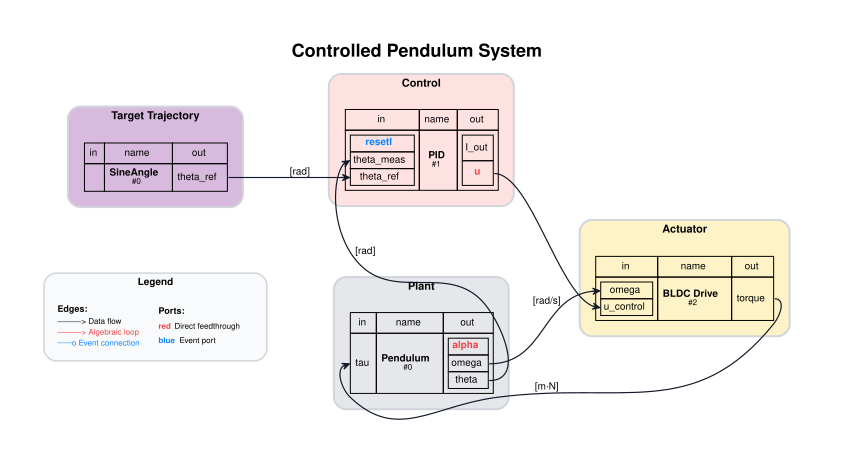

In [34]:
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

## Run Simulation

In [86]:
t = 0.0
dt = 0.01
t_end = 5.0
dt_vals = (0.02, 0.01, 0.001)

histories = {}

for dt in dt_vals:
    system.reset()
    system.initialize(t0=0.0)
    system.run(t0=0.0, tf=t_end, dt=dt)
    histories[f'{dt:.3f}s'] = system.get_history()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

## Plot: Tracking vs Reference

The plot compares the co-simulation trajectories against the monolithic Modelica reference.

The Modelica reference trajectory is following the reference trajectory closely. The co-simulation trajectories depend strongly on the chosen communication step size, with smaller step sizes generally providing better tracking performance. For `dt=0.001s`, the co-simulation trajectory closely follows the reference. 

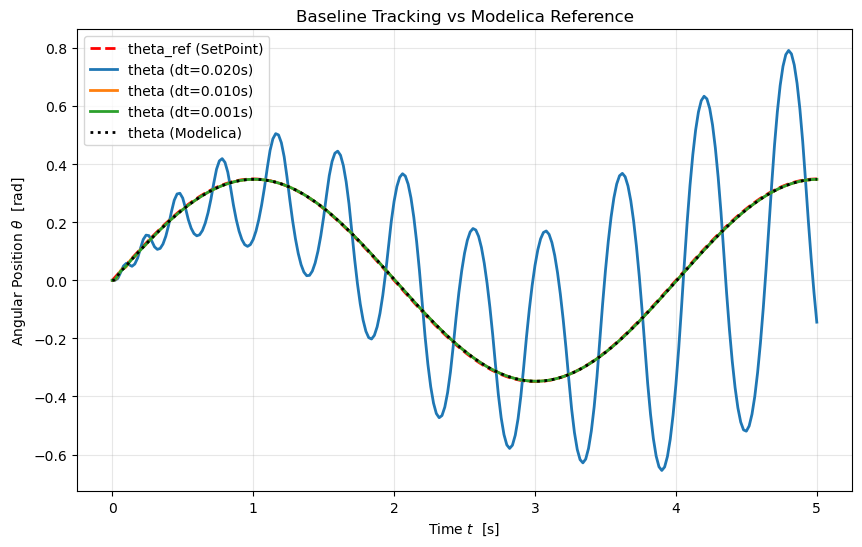

In [105]:
plt.figure(figsize=(10, 6))
plt.plot(histories['0.001s']['SineAngle'][0], histories['0.001s']['SineAngle'][1]['theta_ref'], label="theta_ref (SetPoint)", color="red", linestyle="--", linewidth=2)

for dt, history in histories.items():
    t_pendulum, data = history['Pendulum']
    theta = data['theta']
    plt.plot(t_pendulum, theta, label=f"theta (dt={dt})", linewidth=2)

plt.plot(ref_sol['time'], ref_sol['theta'], label="theta (Modelica)", color='black', linestyle=':', linewidth=2)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Baseline Tracking vs Modelica Reference")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

It can be seen that in the start, the co-simulation trajectories with larger step sizes (e.g., `dt=0.02s`) start oscillating around the reference trajectory. Due to the large communication step size, the controller is not able to react to the changes in the system state quickly enough, leading to overshooting and oscillations. In contrast, the co-simulation trajectory with `dt=0.001s` closely follows the reference trajectory, indicating that the controller can react more effectively to changes in the system state.

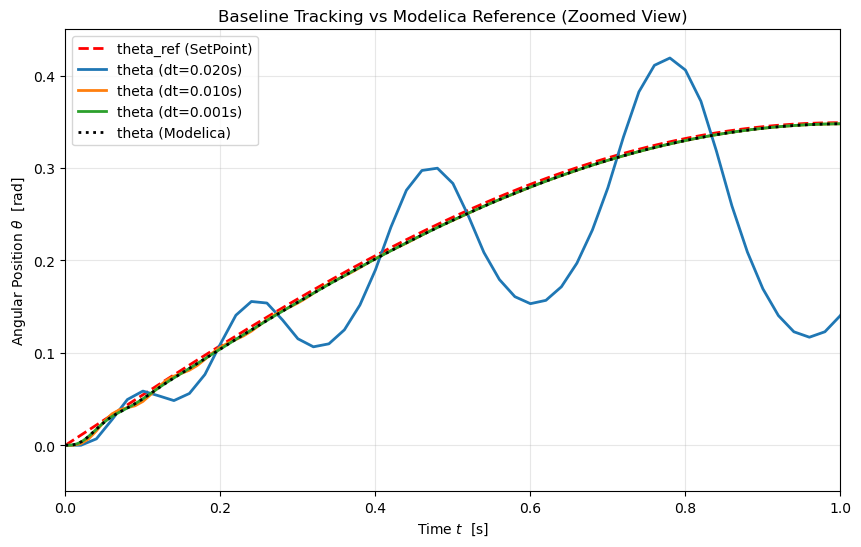

In [106]:
plt.figure(figsize=(10, 6))
plt.plot(histories['0.001s']['SineAngle'][0], histories['0.001s']['SineAngle'][1]['theta_ref'], label="theta_ref (SetPoint)", color="red", linestyle="--", linewidth=2)

for dt, history in histories.items():
    t_pendulum, data = history['Pendulum']
    theta = data['theta']
    plt.plot(t_pendulum, theta, label=f"theta (dt={dt})", linewidth=2)

plt.plot(ref_sol['time'], ref_sol['theta'], label="theta (Modelica)", color='black', linestyle=':', linewidth=2)
plt.xlim(0, 1)
plt.ylim(-0.05, 0.45)
plt.xlabel(r"Time $t$  [s]")
plt.ylabel(r"Angular Position $\theta$  [rad]")
plt.title("Baseline Tracking vs Modelica Reference (Zoomed View)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary
- Co-simulation trajectories match the monolithic reference at the baseline settings for sufficient small communication step sizes.
- This notebook defines the default parameter set used in later case studies.